# Uber & Lyft Cab Price Regression

**Dataset:** [Uber & Lyft Cab Prices](https://www.kaggle.com/datasets/ravi72munde/uber-lyft-cab-prices)  
**Goal:** Predict the price of a cab ride based on ride attributes and weather conditions.

## Steps
1. Load & explore the data
2. Clean & preprocess
3. Feature engineering
4. Train/test split
5. Train models (Linear Regression, Random Forest)
6. Evaluate & compare
7. Compute 95% confidence intervals
8. Build normalized confusion matrix (binned fares) for the paper

In [2]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

## 1. Load Data

Reads `cab_rides.csv` and `weather.csv` directly from the local `archive.zip`.

In [3]:
import zipfile

zip_path = Path('archive.zip')
if not zip_path.exists():
    zip_path = Path('../archive.zip')

if not zip_path.exists():
    raise FileNotFoundError('archive.zip not found in project/ or repository root.')

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('cab_rides.csv') as f:
        rides = pd.read_csv(f)
    with z.open('weather.csv') as f:
        weather = pd.read_csv(f)

rides = rides.sample(n=20_000, random_state=42)

print('Using zip file:', zip_path.resolve())
print('Rides shape:', rides.shape)
print('Weather shape:', weather.shape)
rides.head()

Using zip file: /home/michaeldejournett/Intro-To-Machine-Learning/archive.zip
Rides shape: (20000, 10)
Weather shape: (6276, 8)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
441132,1.89,Uber,1545085210334,Theatre District,Northeastern University,8.0,1.0,ad4dc1c8-74e4-4018-aefe-be4e4b8e1ee5,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
274010,1.97,Lyft,1543366102245,Theatre District,Northeastern University,13.5,1.0,47547461-f88b-4c14-9920-1d4a79e7025f,lyft_plus,Lyft XL
532981,1.35,Uber,1543701476008,North End,Beacon Hill,NaN,1.0,45fba16d-75f1-4e10-bbb7-614f7f1624ae,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
428480,0.91,Uber,1544793611629,Beacon Hill,Haymarket Square,NaN,1.0,79ff5573-1bd4-406d-91c3-5e9b2b60d2b2,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
194181,1.23,Lyft,1544851211219,West End,North End,13.5,1.0,80e33aa2-c291-41f0-b88d-adb3616bf154,lyft_premier,Lux


In [4]:
rides.info()

<class 'pandas.DataFrame'>
Index: 20000 entries, 441132 to 485242
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   distance          20000 non-null  float64
 1   cab_type          20000 non-null  str    
 2   time_stamp        20000 non-null  int64  
 3   destination       20000 non-null  str    
 4   source            20000 non-null  str    
 5   price             18417 non-null  float64
 6   surge_multiplier  20000 non-null  float64
 7   id                20000 non-null  str    
 8   product_id        20000 non-null  str    
 9   name              20000 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 1.7 MB


In [5]:
weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


## 2. Exploratory Data Analysis

In [6]:
print('Missing values in rides:')
print(rides.isnull().sum())
print('\nMissing values in weather:')
print(weather.isnull().sum())

Missing values in rides:
distance               0
cab_type               0
time_stamp             0
destination            0
source                 0
price               1583
surge_multiplier       0
id                     0
product_id             0
name                   0
dtype: int64

Missing values in weather:
temp             0
location         0
clouds           0
pressure         0
rain          5382
time_stamp       0
humidity         0
wind             0
dtype: int64


In [7]:
rides['price'].describe()

count    18417.000000
mean        16.608669
std          9.359916
min          2.500000
25%          9.000000
50%         14.000000
75%         22.500000
max         75.000000
Name: price, dtype: float64

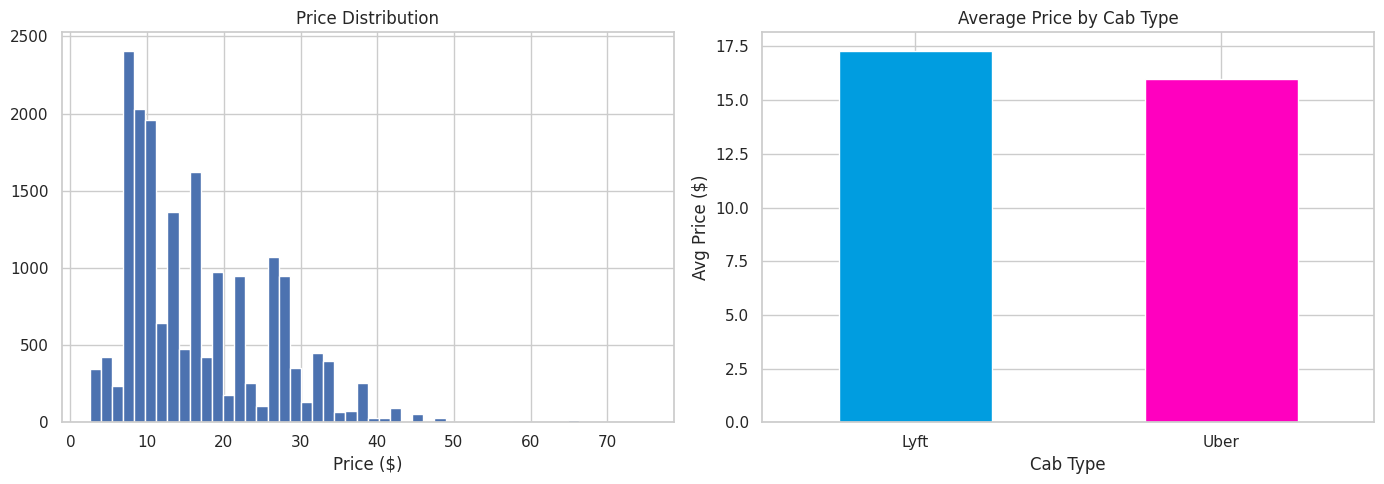

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rides['price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

rides.groupby('cab_type')['price'].mean().plot(kind='bar', ax=axes[1], color=['#009DE0', '#FF00BF'])
axes[1].set_title('Average Price by Cab Type')
axes[1].set_xlabel('Cab Type')
axes[1].set_ylabel('Avg Price ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

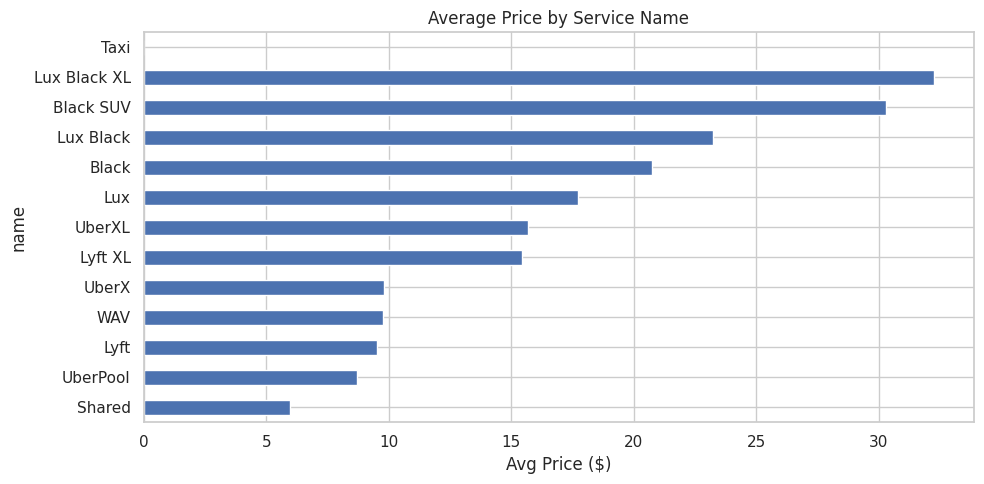

In [9]:
plt.figure(figsize=(10, 5))
rides.groupby('name')['price'].mean().sort_values().plot(kind='barh')
plt.title('Average Price by Service Name')
plt.xlabel('Avg Price ($)')
plt.tight_layout()
plt.show()

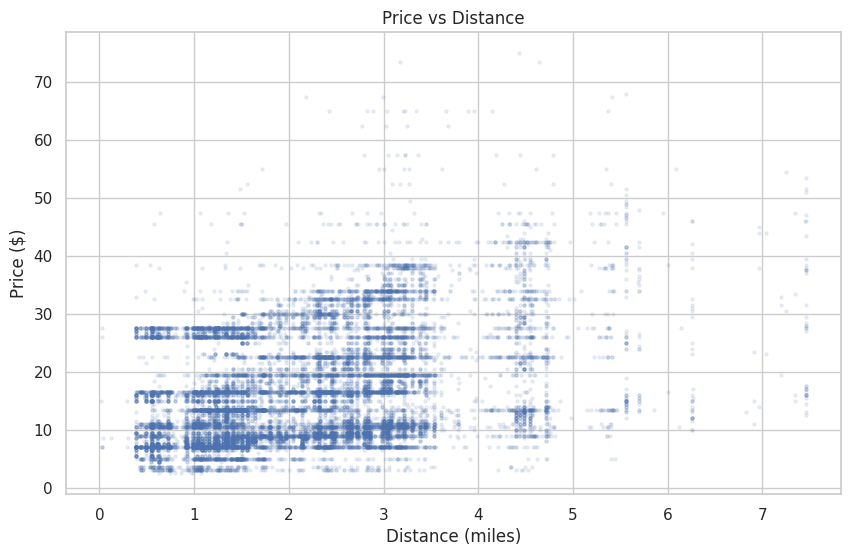

In [10]:
plt.figure()
plt.scatter(rides['distance'], rides['price'], alpha=0.1, s=5)
plt.xlabel('Distance (miles)')
plt.ylabel('Price ($)')
plt.title('Price vs Distance')
plt.show()

## 3. Preprocessing & Feature Engineering

In [11]:
rides.dropna(subset=['price'], inplace=True)

rides['datetime'] = pd.to_datetime(rides['time_stamp'], unit='ms')
rides['hour'] = rides['datetime'].dt.hour
rides['day_of_week'] = rides['datetime'].dt.dayofweek
rides['month'] = rides['datetime'].dt.month

rides['time_stamp_hr'] = (rides['time_stamp'] // 3600000) * 3600
weather['time_stamp_hr'] = (weather['time_stamp'].astype(int) // 3600) * 3600

df = rides.merge(
    weather[['temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind', 'location', 'time_stamp_hr']],
    left_on=['source', 'time_stamp_hr'],
    right_on=['location', 'time_stamp_hr'],
    how='left'
)

matched = df['temp'].notna().sum()
print(f'Merged shape: {df.shape}')
print(f'Weather matched: {matched:,} / {len(df):,} rows ({matched/len(df)*100:.1f}%)')

Merged shape: (34116, 22)
Weather matched: 34,047 / 34,116 rows (99.8%)


In [12]:
for col in ['temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind']:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = ['cab_type', 'name', 'source', 'destination']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

features = [
    'distance', 'hour', 'day_of_week', 'month',
    'temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind',
    'cab_type_enc', 'name_enc', 'source_enc', 'destination_enc'
]

X = df[features].copy()
y = df['price']

X = X.fillna(X.median(numeric_only=True)).fillna(0)

print('Feature matrix shape:', X.shape)
print('Remaining NaNs:', X.isna().sum().sum())
print('surge_multiplier excluded from training features')

Feature matrix shape: (34116, 14)
Remaining NaNs: 0
surge_multiplier excluded from training features


## 4. Correlation Heatmap

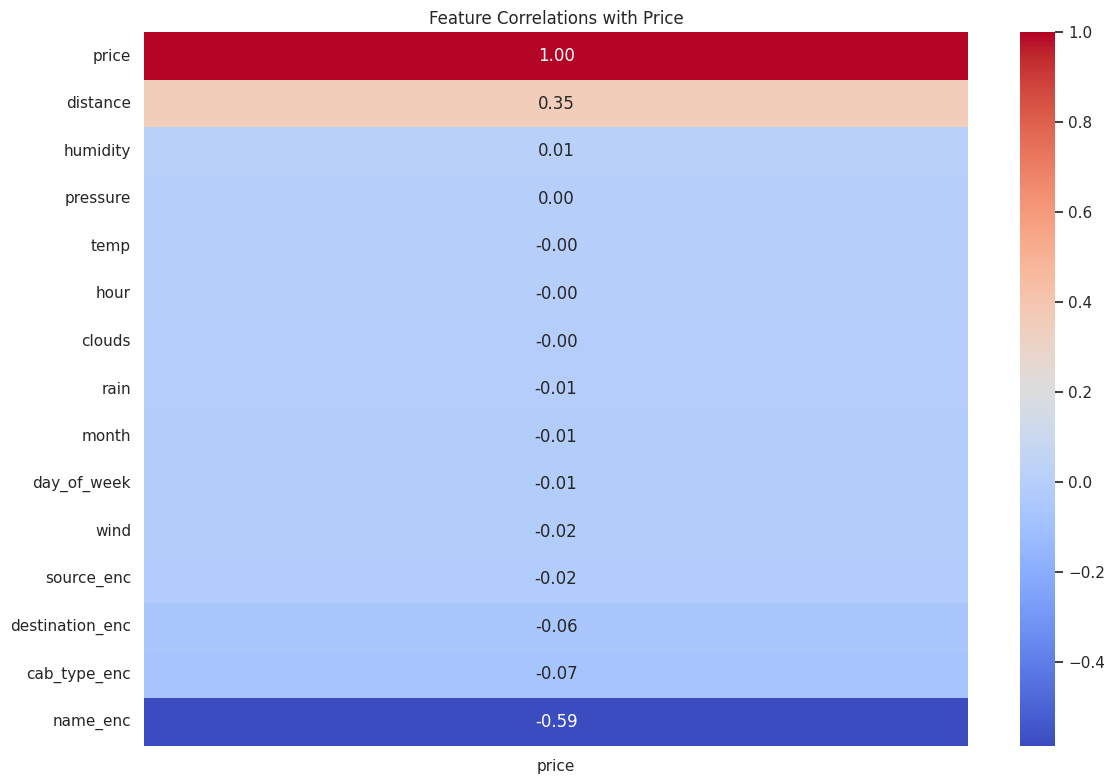

In [13]:
plt.figure(figsize=(12, 8))
corr = X.join(y).corr()
sns.heatmap(corr[['price']].sort_values('price', ascending=False), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations with Price')
plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 27,292 | Test: 6,824


## 6. Train Models

In [15]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    r2   = r2_score(y_te, preds)
    print(f'{name:<30}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')
    return preds, {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

preds_lr, metrics_lr = evaluate('Linear Regression', LinearRegression(), X_train_sc, y_train, X_test_sc, y_test)

rf = RandomForestRegressor(n_estimators=30, max_depth=10, n_jobs=-1, random_state=42)
preds_rf, metrics_rf = evaluate('Random Forest', rf, X_train, y_train, X_test, y_test)

metrics_df = pd.DataFrame([metrics_lr, metrics_rf]).sort_values('MAE').reset_index(drop=True)
best_model_name = metrics_df.loc[0, 'Model']
print(f'\nBest model by MAE: {best_model_name}')
display(metrics_df)

Linear Regression               MAE=5.30  RMSE=6.73  R²=0.4798
Random Forest                   MAE=1.23  RMSE=2.22  R²=0.9431

Best model by MAE: Random Forest


,Model,MAE,RMSE,R2
0,Random Forest,1.226874,2.223966,0.943149
1,Linear Regression,5.296314,6.727564,0.479763


## 7. Visualize Results

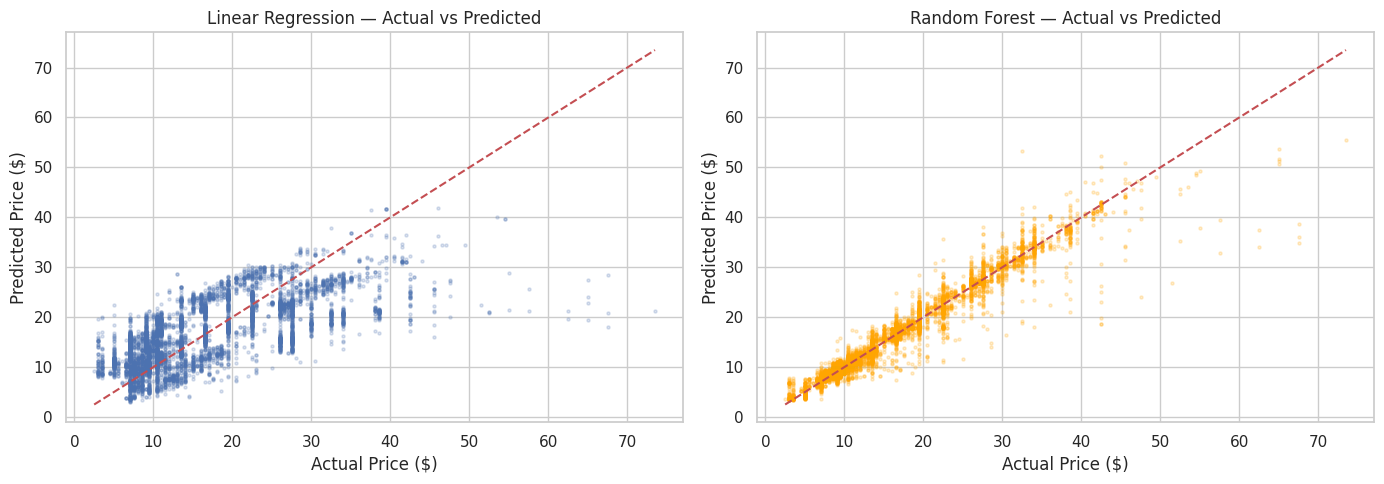

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds_lr, alpha=0.2, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Linear Regression — Actual vs Predicted')

axes[1].scatter(y_test, preds_rf, alpha=0.2, s=5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Random Forest — Actual vs Predicted')

plt.tight_layout()
plt.show()

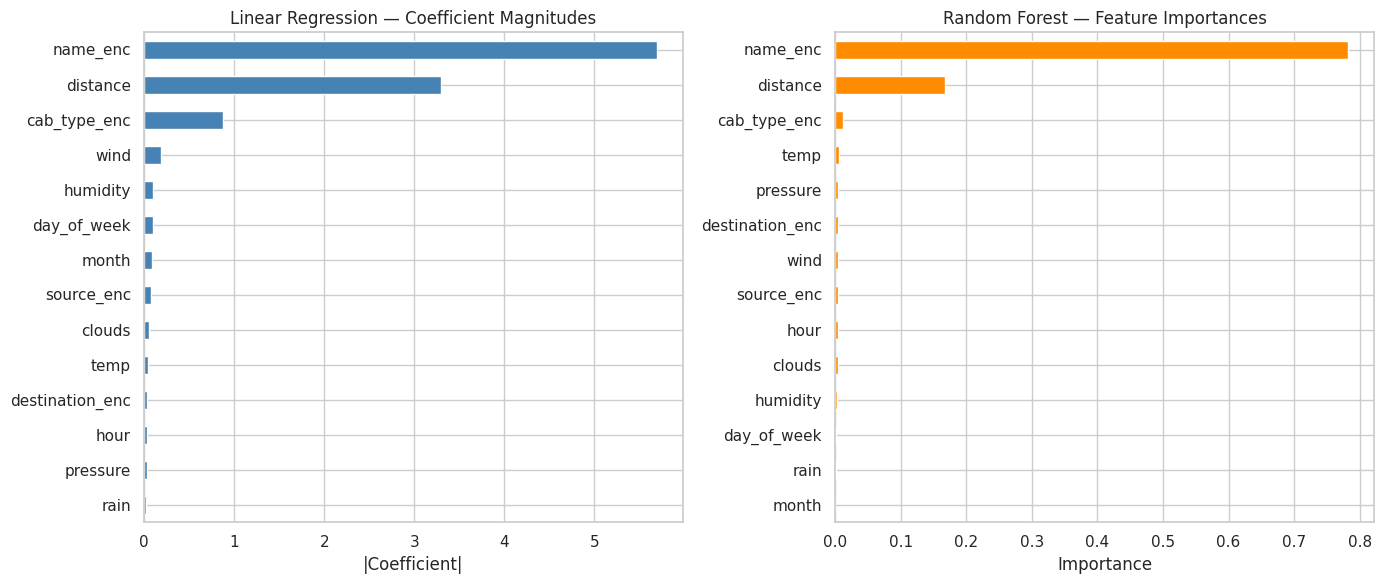

In [21]:
# Feature importance for Random Forest
importances_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Coefficient magnitudes for Linear Regression (need to fit on scaled data to get comparable coefficients)
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
importances_lr = pd.Series(np.abs(lr_model.coef_), index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances_lr.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Linear Regression — Feature Coefficients (abs)')
axes[0].set_xlabel('Coefficients (abs)')

importances_rf.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest — Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8. Paper Metrics: Confidence Intervals & Normalized Confusion Matrix

This section computes 95% confidence intervals for key metrics and generates a normalized confusion matrix (using binned fare ranges) required for the IEEE report.

In [18]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_bootstrap=500, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    stats = []
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        stats.append(metric_fn(y_true_arr[idx], y_pred_arr[idx]))

    alpha = (100 - ci) / 2
    lower, upper = np.percentile(stats, [alpha, 100 - alpha])
    return float(lower), float(upper)

metric_defs = {
    'MAE': mean_absolute_error,
    'RMSE': lambda yt, yp: mean_squared_error(yt, yp) ** 0.5,
    'R2': r2_score
}

pred_map = {
    'Linear Regression': preds_lr,
    'Random Forest': preds_rf
}

rows = []
for model_name, preds in pred_map.items():
    row = {'Model': model_name}
    for metric_name, metric_fn in metric_defs.items():
        point_estimate = metric_fn(y_test, preds)
        ci_low, ci_high = bootstrap_metric_ci(y_test, preds, metric_fn)
        row[metric_name] = point_estimate
        row[f'{metric_name}_CI'] = f'[{ci_low:.3f}, {ci_high:.3f}]'
    rows.append(row)

ci_results_df = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
display(ci_results_df)

ci_results_df.to_csv('paper_metrics_with_ci.csv', index=False)
print('Saved metric summary to project/paper_metrics_with_ci.csv')

,Model,MAE,MAE_CI,RMSE,RMSE_CI,R2,R2_CI
0,Random Forest,1.226874,"[1.182, 1.268]",2.223966,"[2.025, 2.376]",0.943149,"[0.936, 0.952]"
1,Linear Regression,5.296314,"[5.205, 5.396]",6.727564,"[6.564, 6.908]",0.479763,"[0.462, 0.495]"


Saved metric summary to project/paper_metrics_with_ci.csv


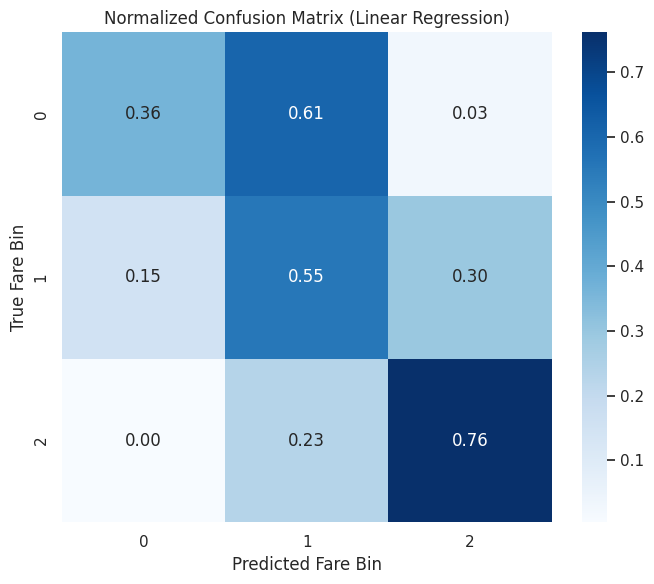

Saved Linear Regression confusion matrix to: /home/michaeldejournett/Intro-To-Machine-Learning/paper/figures/normalized_confusion_matrix_lr.png


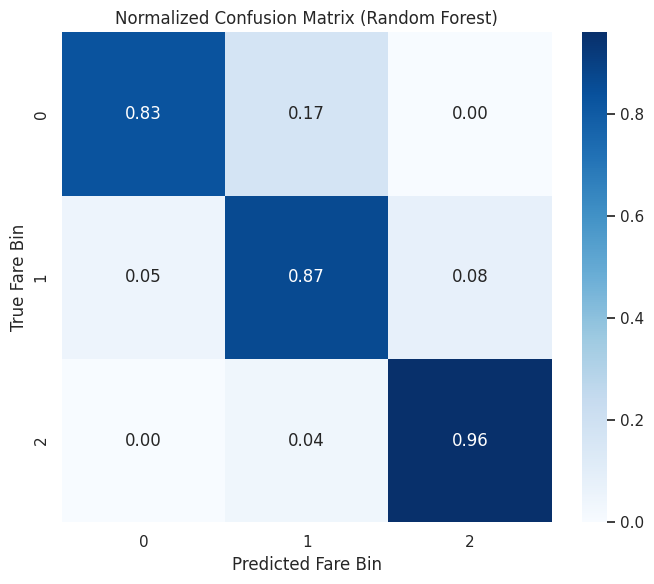

Saved Random Forest confusion matrix to: /home/michaeldejournett/Intro-To-Machine-Learning/paper/figures/normalized_confusion_matrix_rf.png
Bin edges used: [-inf 10.5 19.5  inf]


In [20]:
paper_fig_dir = Path('../paper/figures')
paper_fig_dir.mkdir(parents=True, exist_ok=True)

# Use quantile-based bins from true fares for balanced ranges
n_bins = 3
_, bin_edges = pd.qcut(y_test, q=n_bins, retbins=True, duplicates='drop')
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

y_true_binned = pd.cut(y_test, bins=bin_edges, labels=False, include_lowest=True)
labels = sorted(pd.Series(y_true_binned).dropna().unique())

# Generate confusion matrices for both models
model_preds = {
    'Linear Regression': preds_lr,
    'Random Forest': preds_rf
}

for model_name, preds in model_preds.items():
    y_pred_binned = pd.cut(preds, bins=bin_edges, labels=False, include_lowest=True)
    cm = confusion_matrix(y_true_binned, y_pred_binned, labels=labels, normalize='true')

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=True)
    plt.title(f'Normalized Confusion Matrix ({model_name})')
    plt.xlabel('Predicted Fare Bin')
    plt.ylabel('True Fare Bin')
    plt.tight_layout()

    # Save with model-specific name
    short_name = 'lr' if model_name == 'Linear Regression' else 'rf'
    cm_path = paper_fig_dir / f'normalized_confusion_matrix_{short_name}.png'
    plt.savefig(cm_path, dpi=300)
    plt.show()
    print(f'Saved {model_name} confusion matrix to: {cm_path.resolve()}')

print('Bin edges used:', np.round(bin_edges, 2))

In [22]:
# Export metrics for LaTeX report
print('\n=== METRICS FOR LATEX REPORT ===')
print(f'Best Model: {best_model_name}')
print(f'\nMetrics Table:')
print(ci_results_df.to_string(index=False))

# Extract values for each model
print('\n=== INDIVIDUAL MODEL METRICS ===')
for idx, row in ci_results_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  MAE: {row['MAE']:.2f} {row['MAE_CI']}")
    print(f"  RMSE: {row['RMSE']:.2f} {row['RMSE_CI']}")
    print(f"  R²: {row['R2']:.4f} {row['R2_CI']}")

# Data for LaTeX
best_row = ci_results_df.iloc[0]
best_mae = best_row['MAE']
best_rmse = best_row['RMSE']
best_r2 = best_row['R2']
best_mae_ci = best_row['MAE_CI']
print(f'\n=== FOR ABSTRACT/INTRO ===')
print(f'Best model: {best_model_name}')
print(f'MAE = {best_mae:.2f}, RMSE = {best_rmse:.2f}, R² = {best_r2:.4f}')
print(f'95% CI for MAE: {best_mae_ci}')


=== METRICS FOR LATEX REPORT ===
Best Model: Random Forest

Metrics Table:
            Model      MAE         MAE_CI     RMSE        RMSE_CI       R2          R2_CI
    Random Forest 1.226874 [1.182, 1.268] 2.223966 [2.025, 2.376] 0.943149 [0.936, 0.952]
Linear Regression 5.296314 [5.205, 5.396] 6.727564 [6.564, 6.908] 0.479763 [0.462, 0.495]

=== INDIVIDUAL MODEL METRICS ===

Random Forest:
  MAE: 1.23 [1.182, 1.268]
  RMSE: 2.22 [2.025, 2.376]
  R²: 0.9431 [0.936, 0.952]

Linear Regression:
  MAE: 5.30 [5.205, 5.396]
  RMSE: 6.73 [6.564, 6.908]
  R²: 0.4798 [0.462, 0.495]

=== FOR ABSTRACT/INTRO ===
Best model: Random Forest
MAE = 1.23, RMSE = 2.22, R² = 0.9431
95% CI for MAE: [1.182, 1.268]


In [ ]:
# Export all figures for the paper
import matplotlib.pyplot as plt

print("Exporting figures to paper/figures/...")

# 1. Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds_lr, alpha=0.2, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title('Linear Regression — Actual vs Predicted', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, preds_rf, alpha=0.2, s=5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price ($)', fontsize=11)
axes[1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[1].set_title('Random Forest — Actual vs Predicted', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
actual_vs_pred_path = paper_fig_dir / 'actual_vs_predicted.png'
plt.savefig(actual_vs_pred_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {actual_vs_pred_path}")
plt.close()

# 2. Feature importance plots
importances_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
lr_model_new = LinearRegression()
lr_model_new.fit(X_train_sc, y_train)
importances_lr = pd.Series(np.abs(lr_model_new.coef_), index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances_lr.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Linear Regression — Feature Coefficients (abs)', fontsize=12)
axes[0].set_xlabel('Coefficients (abs)', fontsize=11)

importances_rf.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest — Feature Importances', fontsize=12)
axes[1].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
feature_importance_path = paper_fig_dir / 'feature_importance.png'
plt.savefig(feature_importance_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {feature_importance_path}")
plt.close()

print("\n✓ All figures exported successfully!")


## 9. Summary

| Model | Key Strength |
|---|---|
| Linear Regression | Fast, interpretable baseline — assumes linear relationships |
| Random Forest | Handles non-linearity, provides feature importance |

**Key predictors** are `name` (service tier), `distance`, and time/location-related features.

**Feature choice note:** `surge_multiplier` was intentionally removed from model inputs to avoid using a near-direct pricing factor when predicting price.